## **Infant expression generation using stabilityai/stable-diffusion-3.5-medium**

### Mount Google Drive

In [2]:
from google.colab import drive
drive.mount('/content/drive')

print("✅ Google Drive mounted!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Google Drive mounted!


### Install Dependencies

In [3]:
# Install core dependencies
!pip install -q torch torchvision diffusers transformers peft accelerate
!pip install -q xformers bitsandbytes
!pip install -q wandb huggingface_hub datasets pillow opencv-python numpy scipy tqdm
!pip install -q scikit-learn torchmetrics

# Disable torchao in PEFT
import os
os.environ["PEFT_DISABLE_TORCHAO"] = "1"

print("✅ Dependencies installed!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 68.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.9/40.9 MB 66.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 37.5 MB/s eta 0:00:00
✅ Dependencies installed!


### Clone Git Repository

In [4]:
# Remove existing directory if it exists
!rm -rf /content/InfantEmotionGen

# Clone your repository
!git clone https://github.com/JessicaHenson01/InfantEmotionGen.git /content/InfantEmotionGen

# Change to the repository directory
%cd /content/InfantEmotionGen

print("✅ Repository cloned!")

Cloning into '/content/InfantEmotionGen'...
remote: Enumerating objects: 1654, done.
remote: Counting objects: 100% (145/145), done.
remote: Compressing objects: 100% (89/89), done.
remote: Total 1654 (delta 127), reused 74 (delta 56), pack-reused 1509 (from 2)
Receiving objects: 100% (1654/1654), 65.15 MiB | 31.71 MiB/s, done.
Resolving deltas: 100% (324/324), done.
/content/InfantEmotionGen
✅ Repository cloned!


### Create Data Directory and Copy Data

In [5]:
# Create data directory
!mkdir -p /content/InfantEmotionGen/data

# Copy ZIP file from Google Drive
!cp /content/drive/MyDrive/baby_emotion_samples.zip /content/InfantEmotionGen/data/

# Copy JSON file from Google Drive
!cp /content/drive/MyDrive/baby_emotion_samples.json /content/InfantEmotionGen/data/

print("✅ Dataset copied from Google Drive!")

✅ Dataset copied from Google Drive!


### Prepare Dataset

In [6]:
import zipfile
import json
import os

# Unzip dataset
zip_path = "/content/InfantEmotionGen/data/baby_emotion_samples.zip"
extract_path = "/content/InfantEmotionGen/data/"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("✅ Dataset unzipped!")

# Format JSON labels
json_path = "/content/InfantEmotionGen/data/baby_emotion_samples.json"

if os.path.exists(json_path):
    with open(json_path, 'r') as f:
        data = json.load(f)

    if "labels" in data and isinstance(data["labels"], list):
        labels_dict = {}
        for item in data["labels"]:
            if isinstance(item, list) and len(item) >= 2:
                labels_dict[item[0]] = item[1]

        with open("/content/InfantEmotionGen/data/labels_formatted.json", 'w') as f:
            json.dump(labels_dict, f, indent=2)

        print("✅ Created formatted labels file: labels_formatted.json")
        print(f"   {len(labels_dict)} entries saved")

print("✅ Dataset ready!")

✅ Dataset unzipped!
✅ Created formatted labels file: labels_formatted.json
   1200 entries saved
✅ Dataset ready!


### W&B and Huggingface Login

In [7]:
import wandb
from huggingface_hub import login

# Login to WandB
print("🔑 Please log in to WandB...")
wandb.login()

# Login to Hugging Face
print("🔑 Please log in to Hugging Face...")
login()

print("✅ Logged in to WandB and Hugging Face!")

🔑 Please log in to WandB...


/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results


wandb: Enter your choice: 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.


wandb: Paste your API key and hit enter: ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: rahuldey-mle (rahuldey-mle-johns-hopkins-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


🔑 Please log in to Hugging Face...


✅ Logged in to WandB and Hugging Face!


In [8]:
from huggingface_hub import login

# Login with your token
# Get your token from: https://huggingface.co/settings/tokens
login()

print("✅ Logged in to Hugging Face!")

✅ Logged in to Hugging Face!


In [9]:
from huggingface_hub import whoami

try:
    user_info = whoami()
    print(f"✅ Logged in as: {user_info['name']}")
except Exception as e:
    print(f"❌ Login failed: {e}")

✅ Logged in as: panda-hf


### Uninstall torchao

In [10]:
!pip uninstall torchao -y
print("✅ torchao uninstalled")

Found existing installation: torchao 0.10.0
Uninstalling torchao-0.10.0:
  Successfully uninstalled torchao-0.10.0
✅ torchao uninstalled


### Training

In [12]:
# Clone the official diffusers repo and use their script
%cd /content/InfantEmotionGen

!python src/stable_diffusion_35/train_dreambooth_lora_sd35.py \
  --data_dir ./data/baby_emotion_samples \
  --json_path ./data/labels_formatted.json \
  --output_dir ./models/infant_lora_sd35 \
  --wandb_project "infant-emotion-generation" \
  --wandb_run_name "sd35-timestep-fix" \
  --instance_prompt_template "a photo of a {} sks infant" \
  --resolution 512 \
  --train_batch_size 1 \
  --gradient_accumulation_steps 4 \
  --learning_rate 1e-4 \
  --max_train_steps 1500 \
  --checkpoint_steps 500 \
  --seed 42



/content/InfantEmotionGen
Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.
wandb: Currently logged in as: rahuldey-mle (rahuldey-mle-johns-hopkins-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: Using an existing wandb-core service via WANDB_SERVICE.
wandb: ⢿ setting up run pewgdfzy (0.0s)
wandb: ⣻ setting up run pewgdfzy (0.0s)
wandb: Tracking run with wandb version 0.28.0
wandb: Run data is saved locally in /content/InfantEmotionGen/wandb/run-20260806_001214-pewgdfzy
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run sd35-timestep-fix
wandb: ⭐️ View project at https://wandb.ai/rahuldey-mle-johns-h

### Save Trained Model to Google Drive

In [13]:
!cp -r /content/InfantEmotionGen/models/infant_lora_sd35 /content/drive/MyDrive/model/

### Inference

In [14]:
%cd /content/InfantEmotionGen

!python src/stable_diffusion_35/generate_infant_faces_sd35.py \
  --lora_path ./models/infant_lora_sd35/mmdit_lora_final \
  --output_dir ./generated_images/sd35 \
  --num_images 100

/content/InfantEmotionGen
Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
[transformers] `Siglip2ImageProcessorFast` is deprecated. The `Fast` suffix for image processors has been removed; use `Siglip2ImageProcessor` instead.
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.
wandb: Currently logged in as: rahuldey-mle (rahuldey-mle-johns-hopkins-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: Using an existing wandb-core service via WANDB_SERVICE.
wandb: ⢿ setting up run zk89yfl5 (0.0s)
wandb: ⣻ setting up run zk89yfl5 (0.0s)
wandb: ⣽ setting up run zk89yfl5 (0.0s)
wandb: ⣾ setting up run zk89yfl5 (0.0s)
wandb: ⣷ setting up run zk89yfl5 (0.5s)
wandb: ⣯ setting up

### Project Backup

In [15]:
!cp -r /content/InfantEmotionGen /content/drive/MyDrive/

### Display Images

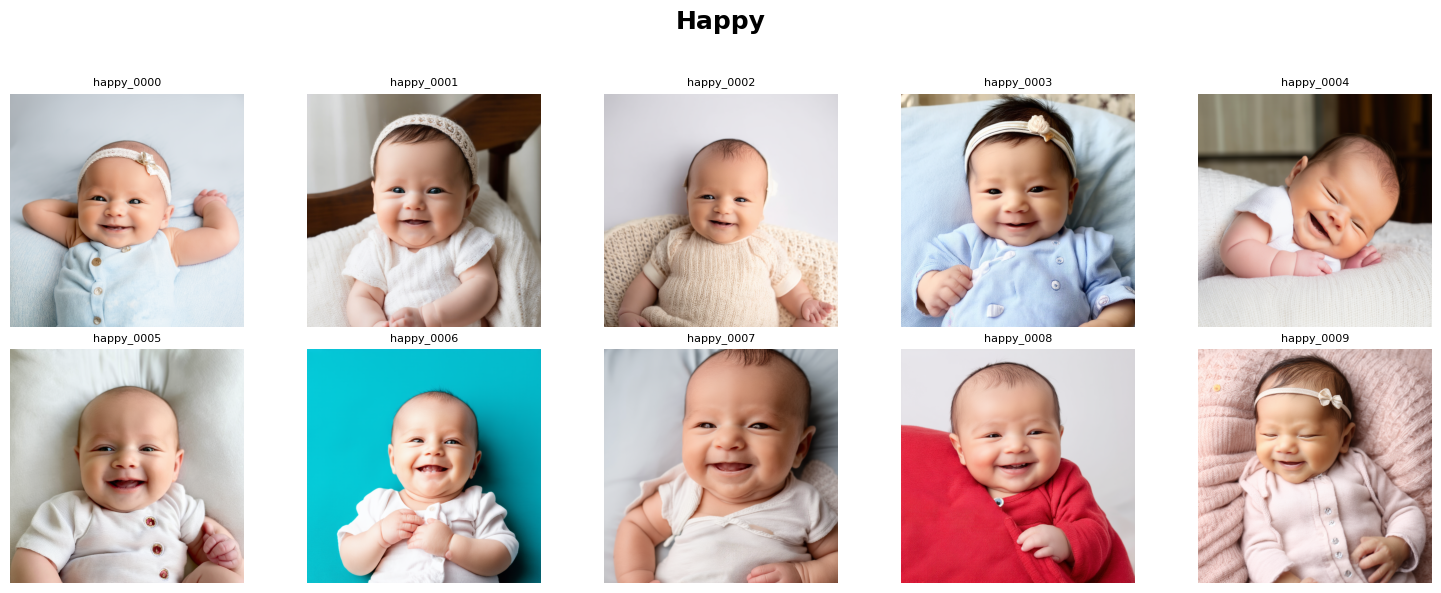

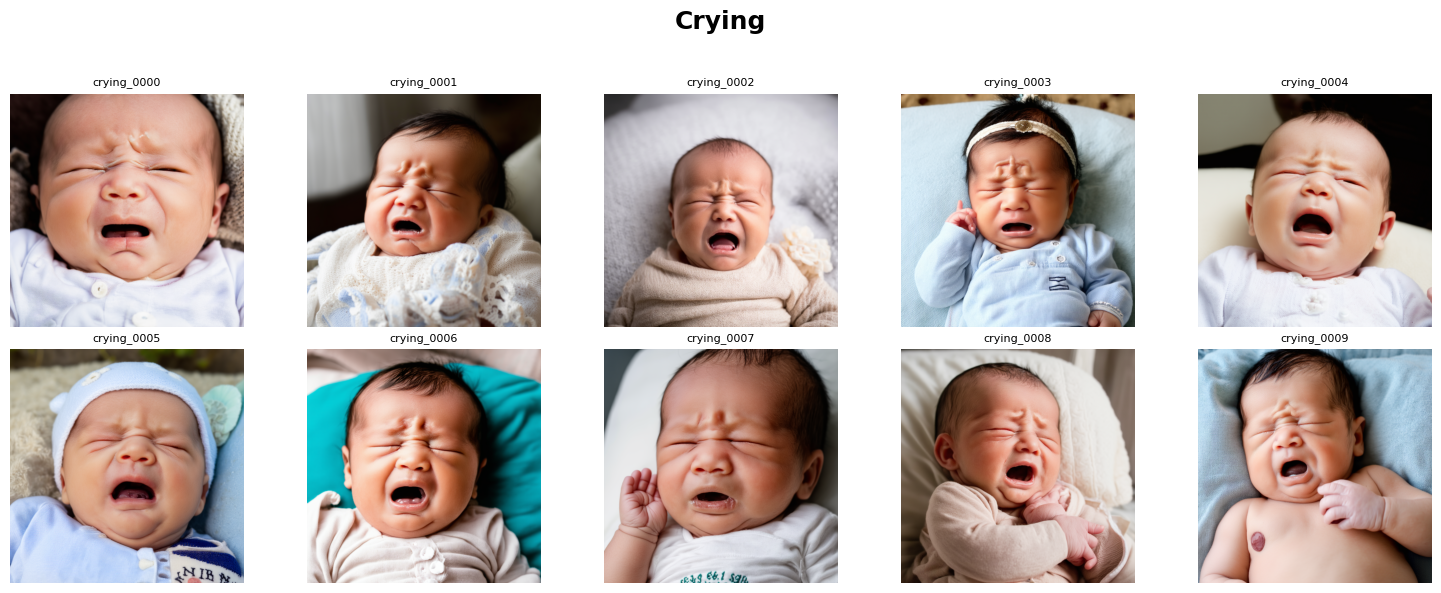

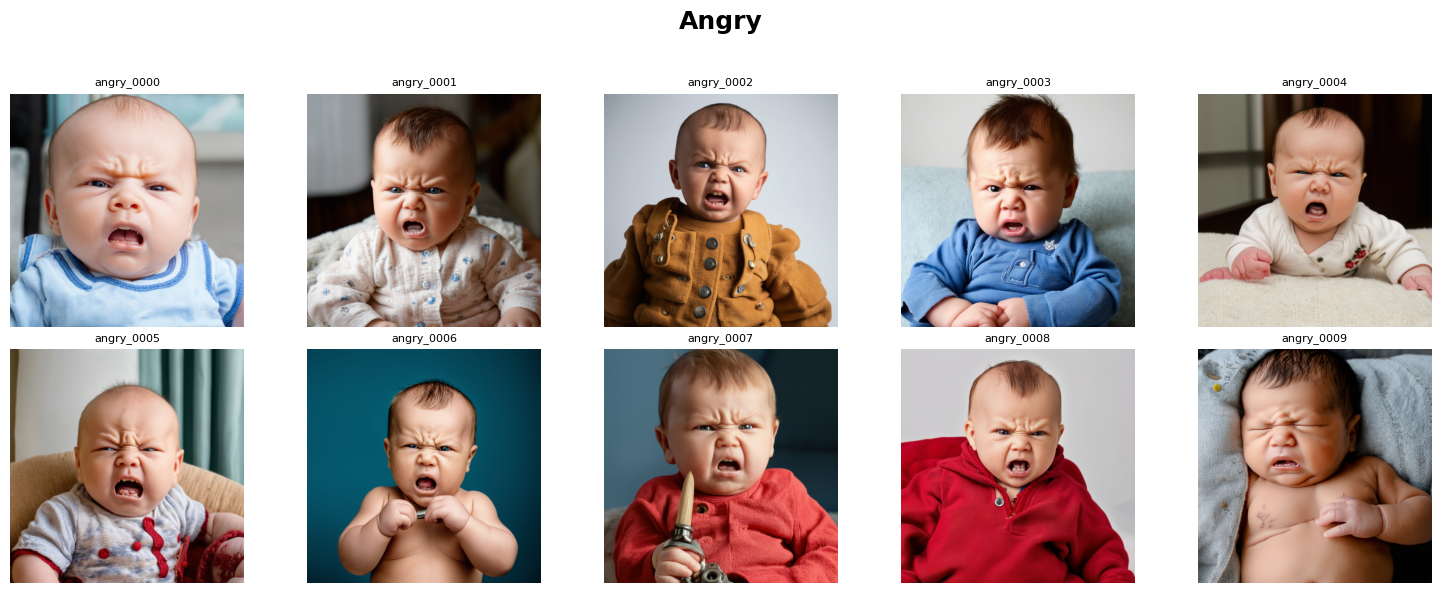

In [17]:
import os
from PIL import Image
import matplotlib.pyplot as plt

# Folder paths
folders = {
    "Happy": "/content/InfantEmotionGen/generated_images/sd35/happy",
    "Crying": "/content/InfantEmotionGen/generated_images/sd35/crying",
    "Angry": "/content/InfantEmotionGen/generated_images/sd35/angry",
}

images_per_row = 5
max_images = 10  # Display only the first 10 images

for title, folder in folders.items():
    # Get first 10 PNG images
    image_files = sorted(
        [f for f in os.listdir(folder) if f.lower().endswith(".png")]
    )[:max_images]

    rows = (len(image_files) + images_per_row - 1) // images_per_row
    fig, axes = plt.subplots(rows, images_per_row, figsize=(15, 3 * rows))

    # Flatten axes into a 1D list
    if rows == 1:
        axes = axes.ravel()
    else:
        axes = axes.flatten()

    fig.suptitle(title, fontsize=18, fontweight="bold")

    # Hide all axes initially
    for ax in axes:
        ax.axis("off")

    # Display images
    for i, img_name in enumerate(image_files):
        img = Image.open(os.path.join(folder, img_name))
        axes[i].imshow(img)
        axes[i].set_title(os.path.splitext(img_name)[0], fontsize=8)
        axes[i].axis("off")

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()